# ANALYSIS FOR YEAR 2025 - PILOT 2 DATASET

In [48]:
start_date="2025-01-01"
end_date="2026-01-01"
#start_date="2025-01-01"
#end_date="2025-07-31"

In [49]:
import common as common
import common_test as common_test

In [50]:
import json

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
API_SERVER="https://api.cssboost.particle-summary.pt"

In [53]:
token="..."

In [54]:
# check valid token
ENDPOINT_USER=API_SERVER+"/rest-auth/user"
(result, data)=common.get_data(ENDPOINT_USER, token, None)

-- get from  https://api.cssboost.particle-summary.pt/rest-auth/user
-- data GET OK.


In [55]:
if result == 200:
    print("-- result OK ", result, data)
else:
    raise SystemExit("-- token invalid? result NOK. code=", result)


-- result OK  200 {'pk': 2, 'username': 'particle+admin@particle-summary.pt', 'email': 'particle+admin@particle-summary.pt', 'first_name': 'particlesummary', 'last_name': 'User', 'person_external_id': '5813eb25-0e31-4f09-9c45-56e01697498b'}


# Pilot Analysis

In [56]:
PILOT="pilot_2"

In [57]:
DATASET="pilot_2_dataset_1"

In [58]:
ENDPOINT_PILOT=API_SERVER+"/pilots/"+PILOT

In [59]:
ENDPOINT_DATASET=API_SERVER+"/pilots/"+PILOT+"/datasets/"+DATASET

## Basic operations - get pilot and related datasets entities

In [60]:
(result, data)=common.get_data(ENDPOINT_PILOT, token, None)

-- get from  https://api.cssboost.particle-summary.pt/pilots/pilot_2
-- data GET OK.


In [61]:
print(data)

{'external_id': 'pilot_2', 'name': 'Pilot 2', 'description': 'Pilot 2: Wastewater Reuse and Nutrients Recovery demonstrates circular solutions for wastewater reuse and nutrient recovery.'}


In [62]:
(result, data)=common.get_data(ENDPOINT_PILOT+"/datasets", token, None)

-- get from  https://api.cssboost.particle-summary.pt/pilots/pilot_2/datasets
-- data GET OK.


In [63]:
print(data)

{'items': [{'external_id': 'pilot_2_dataset_1', 'name': 'Wastewater treatment plant', 'description': 'Dataset from the wastewater treatment plant and new reuse facilities, responsible for water quality and infrastructure.\r\nThis is a HIGH RESOLUTION dataset.', 'sharing_policy': 'CLOSED', 'start_date': None, 'end_date': None, 'duration': None, 'groups': [], 'roles': []}, {'external_id': 'pilot_2_dataset_low_res', 'name': 'Wastewater treatment plant [low resolution]', 'description': 'Dataset from the wastewater treatment plant and new reuse facilities, responsible for water quality and infrastructure.This is a low-resolution dataset for year 2024.', 'sharing_policy': 'SHARED', 'start_date': '2024-01-01T00:00:00Z', 'end_date': '2027-12-31T00:00:00Z', 'duration': 0, 'groups': ['guest', 'user', 'manager'], 'roles': ['research']}, {'external_id': 'pilot_2_dataset_2', 'name': 'Wastewater treatment plant (files)', 'description': 'Files constituting the dataset from the wastewater treatment pl

In [64]:
(result, data)=common.get_data(ENDPOINT_DATASET, token, None)

-- get from  https://api.cssboost.particle-summary.pt/pilots/pilot_2/datasets/pilot_2_dataset_1
-- data GET OK.


In [65]:
print(data)

{'external_id': 'pilot_2_dataset_1', 'name': 'Wastewater treatment plant', 'description': 'Dataset from the wastewater treatment plant and new reuse facilities, responsible for water quality and infrastructure.\r\nThis is a HIGH RESOLUTION dataset.', 'sharing_policy': 'CLOSED', 'start_date': None, 'end_date': None, 'duration': None, 'groups': [], 'roles': []}


## Setting properties

Generated data can be related with physical properties, involving metrics and units.  These need to be setup.

In [66]:
ENDPOINT_PROPERTIES=API_SERVER+"/properties"

In [67]:
(result, properties)=common.get_data(ENDPOINT_PROPERTIES, token, None)

-- get from  https://api.cssboost.particle-summary.pt/properties
-- data GET OK.


In [68]:
#print(properties)

In [69]:
# add unit
for prop in properties:
    prop["unit"]=prop["keys"][0]["unit"]
df_prop = pd.DataFrame(properties).reindex(columns=["code", "value_type", "unit"]) #["code", "value_type"]
print(df_prop)

                       code               value_type    unit
0                PARAM00001                       pH       1
1                PARAM00006   Total Suspended Solids    mg/l
2                PARAM00007                      BOD    mg/l
3                PARAM00008                      COD    mg/l
4                PARAM00032    Total Phosphorus (TP)    mg/l
5                PARAM00033           Ammonium (NH4)    mg/l
6                PARAM00034                  Nitrite    mg/l
7                PARAM00035           Nitrate (NO3⁻)    mg/l
8                PARAM00036             Oil & Grease    mg/l
9                PARAM00037       Total Hydrocarbons    mg/l
10               PARAM00042        Total Surfactants    mg/l
11               PARAM00050                   E.Coli    mg/l
12               PARAM00052      Total Nitrogen (TN)    mg/l
13               PARAM00059                 Nitrates    mg/l
14               PARAM00060            Silica (SiO₂)    mg/l
15               PARAM00

<Axes: ylabel='count'>

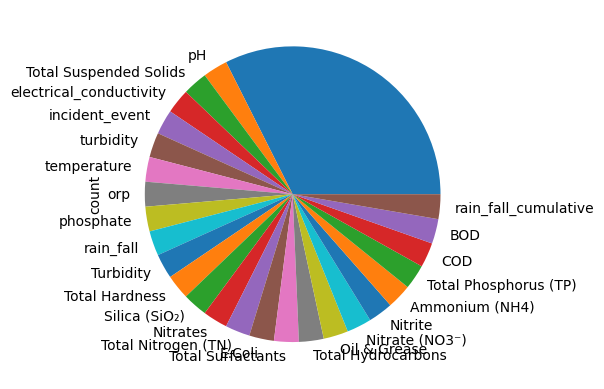

In [70]:
df_prop['value_type'].value_counts().plot(kind='pie')

## Setting device types

In [71]:
ENDPOINT_DEVICE_TYPES=API_SERVER+"/devices/device_types"

In [72]:
(result, device_types)=common.get_data(ENDPOINT_DEVICE_TYPES, token, None)

-- get from  https://api.cssboost.particle-summary.pt/devices/device_types
-- data GET OK.


In [73]:
for dt in device_types:
    if "properties" in dt and len(dt["properties"])>0:
        dt["properties"]=dt["properties"][0]["code"]
    else:
        dt["properties"]="-"
df_dtypes = pd.DataFrame(device_types).reindex(columns=["external_id", "name", "properties"]) #["code", "value_type"]
print(df_dtypes)

                       external_id                            name  \
0                          generic                         Generic   
1                    report_source                   Report Source   
2                        ph_sensor                       pH Sensor   
3                  ammonium_sensor                 Ammonium Sensor   
4                       cod_sensor                      COD Sensor   
5                   nitrate_sensor                  nitrate_sensor   
6                 phosphate_sensor                phosphate_sensor   
7                       orp_sensor                      orp_sensor   
8                  incident_sensor                 incident_sensor   
9                        rain_fall                       rain_fall   
10                chlorides_sensor                Chlorides Sensor   
11              temperature_sensor              Temperature Sensor   
12                turbidity_sensor                       Turbidity   
13                  

In [74]:
sensors_info = common.read_file("/Users/marco/software/particle/cssboost/pilot-data-import/pilot-2-water/sensors_info.json")
print(sensors_info)

{'CDEPUR00198DESB67_MISU10_MFPOR1': {'type': 'flow_sensor', 'property': 'flow_rate', 'unit': 'm3/h'}, 'CDEPUR00198DESB67_MISU11_MFPOR1': {'type': 'flow_sensor', 'property': 'flow_rate', 'unit': 'm3/h'}, 'CDEPUR00198DESB67_MISU15_MFPOR1': {'type': 'flow_sensor', 'property': 'flow_rate', 'unit': 'm3/h'}, 'CDEPUR00198DESB67_MISU20_MFPOR1': {'type': 'flow_sensor', 'property': 'flow_rate', 'unit': 'm3/h'}, 'CDEPUR00198DESB67_MISU22_MFCND1': {'type': 'electrical_conductivity_sensor', 'property': 'electrical_conductivity', 'unit': 'mS/cm'}, 'CDEPUR00198DESB67_PLUV01_MFDAY1': {'type': 'rain_fall_cumulative', 'property': 'rain_fall_cumulative', 'unit': 'mm'}, 'CDEPUR00198DESB67_STAZ05_MFAMMO': {'type': 'ammonium_sensor', 'property': 'PARAM00033', 'unit': 'mg/l'}, 'CDEPUR00198DESB67_STAZ05_MFCLOR': {'type': 'chlorides_sensor', 'property': 'chlorides', 'unit': 'mg/l'}, 'CDEPUR00198DESB67_STAZ05_MFCOD1': {'type': 'cod_sensor', 'property': 'PARAM00008', 'unit': 'mg/l'}, 'CDEPUR00198DESB67_STAZ05_MF

In [75]:
df_sensors_info = pd.DataFrame(sensors_info).T.reindex(columns=["type", "property"])
print(df_sensors_info)

                                                           type  \
CDEPUR00198DESB67_MISU10_MFPOR1                     flow_sensor   
CDEPUR00198DESB67_MISU11_MFPOR1                     flow_sensor   
CDEPUR00198DESB67_MISU15_MFPOR1                     flow_sensor   
CDEPUR00198DESB67_MISU20_MFPOR1                     flow_sensor   
CDEPUR00198DESB67_MISU22_MFCND1  electrical_conductivity_sensor   
CDEPUR00198DESB67_PLUV01_MFDAY1            rain_fall_cumulative   
CDEPUR00198DESB67_STAZ05_MFAMMO                 ammonium_sensor   
CDEPUR00198DESB67_STAZ05_MFCLOR                chlorides_sensor   
CDEPUR00198DESB67_STAZ05_MFCOD1                      cod_sensor   
CDEPUR00198DESB67_STAZ05_MFNITR                  nitrate_sensor   
CDEPUR00198DESB67_STAZ05_MFPH00                       ph_sensor   
CDEPUR00198DESB67_STAZ05_MFPO4P                phosphate_sensor   
CDEPUR00198DESB67_STAZ05_MFREDX                      orp_sensor   
CDEPUR00198DESB67_STAZ05_MFTEMP              temperature_senso

<Axes: ylabel='count'>

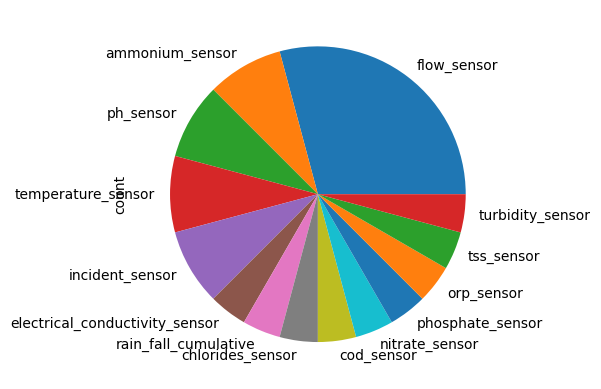

In [76]:
df_sensors_info['type'].value_counts().plot(kind='pie')

<Axes: ylabel='type'>

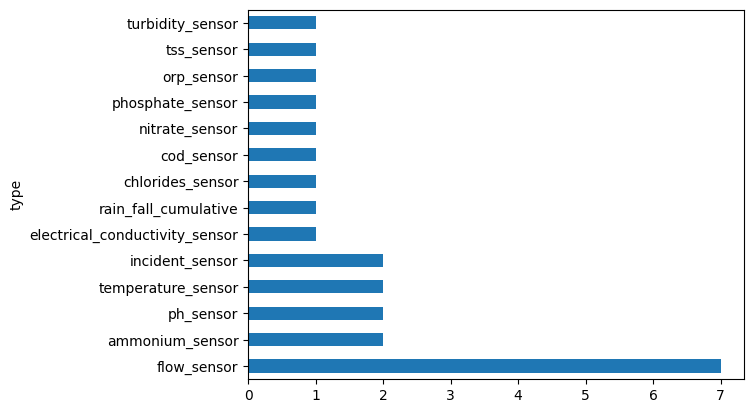

In [77]:
df_sensors_info['type'].value_counts().plot(kind='barh')

# DEVICE RELATIONS

In [78]:
print("- PILOT:", PILOT, "\n- DATASET:", DATASET)

- PILOT: pilot_2 
- DATASET: pilot_2_dataset_1


In [79]:
ENDPOINT_DATASET_DEVICES=API_SERVER+"/pilots/"+PILOT+"/datasets/"+DATASET+"/device"

In [80]:
(result, dataset_devices)=common.get_data(ENDPOINT_DATASET_DEVICES, token, None)

-- get from  https://api.cssboost.particle-summary.pt/pilots/pilot_2/datasets/pilot_2_dataset_1/device
-- data GET OK.


In [81]:
d=[]
for dr in dataset_devices["items"]:
    d.append(dr["device"])
df_dataset_devices = pd.DataFrame(d).reindex(columns=["name", "deviceType"])
print(df_dataset_devices)

                               name                      deviceType
0   CDEPUR00198DESB67_MISU10_MFPOR1                     flow_sensor
1   CDEPUR00198DESB67_MISU11_MFPOR1                     flow_sensor
2   CDEPUR00198DESB67_MISU15_MFPOR1                     flow_sensor
3   CDEPUR00198DESB67_MISU20_MFPOR1                     flow_sensor
4   CDEPUR00198DESB67_MISU22_MFCND1  electrical_conductivity_sensor
5   CDEPUR00198DESB67_PLUV01_MFDAY1            rain_fall_cumulative
6   CDEPUR00198DESB67_STAZ03_MFPH00                       ph_sensor
7   CDEPUR00198DESB67_STAZ03_MFTEMP              temperature_sensor
8   CDEPUR00198DESB67_STAZ03_MFTORB                turbidity_sensor
9   CDEPUR00198DESB67_STAZ05_MFAMMO                 ammonium_sensor
10  CDEPUR00198DESB67_STAZ05_MFCLOR                chlorides_sensor
11  CDEPUR00198DESB67_STAZ05_MFCOD1                      cod_sensor
12  CDEPUR00198DESB67_STAZ05_MFNITR                  nitrate_sensor
13  CDEPUR00198DESB67_STAZ05_MFPH00             

<Axes: ylabel='deviceType'>

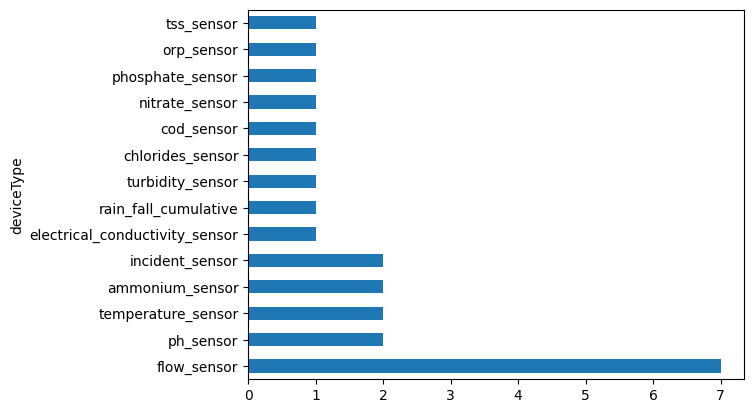

In [82]:
df_dataset_devices['deviceType'].value_counts().plot(kind='barh')

# REPORT-SOURCE relations

In [83]:
print("- PILOT:", PILOT, "\n- DATASET:", DATASET)

- PILOT: pilot_2 
- DATASET: pilot_2_dataset_1


In [84]:
ENDPOINT_DATASET_REPORT=API_SERVER+"/pilots/"+PILOT+"/datasets/"+DATASET+"/data-report"

In [85]:
(result, dataset_report)=common.get_data(ENDPOINT_DATASET_REPORT, token, None)

-- get from  https://api.cssboost.particle-summary.pt/pilots/pilot_2/datasets/pilot_2_dataset_1/data-report
-- data GET OK.


In [86]:
d=[]
for dr in dataset_report["items"]:
    d.append(dr["source"])
df_dataset_source = pd.DataFrame(d).reindex(columns=["name", "deviceType"])
print(df_dataset_source)

                name     deviceType
0  POZZETTO INGRESSO  report_source
1    POZZETTO USCITA  report_source
2     MICROBIOLOGICO  report_source


# DEVICES (from dataset)

In [87]:
ENDPOINT_GET_DEVICES=API_SERVER+"/devices/"
ENDPOINT_GET_DEVICE_ID_DATA_EVENTS_PROP=API_SERVER+"/devices/%s/data/events/%s"
ENDPOINT_GET_DEVICE_ID_DATA_STATS_PROP=API_SERVER+"/devices/%s/data/statistics/%s/keys/%s?statistics=%s"
ENDPOINT_GET_DEVICE_ID_DATA_STATS_NESTED=API_SERVER+"/devices/%s/data/statistics/nested/date/%s/keys/%s?statistics=%s&group_by=%s"
#properties="flow_rate"
#stats="avg,min,max,sum,count"
stats="count"
keys="value"

In [88]:
(result, devices)=common.get_data(ENDPOINT_GET_DEVICES, token, None)

-- get from  https://api.cssboost.particle-summary.pt/devices/
-- data GET OK.


In [89]:
print("-- nbr devices ", len(devices["items"]))

-- nbr devices  24


## Stats (overall)

In [90]:
# totals
stats="count"
devices_stats={}
for index, row in df_sensors_info.iterrows():
    endpoint = ENDPOINT_GET_DEVICE_ID_DATA_STATS_PROP % ( index, row["property"], keys, stats ) + "&start_date="+start_date+"&end_date="+end_date
    (result, data) = common.get_data(endpoint, token, None)
    print(result, data)
    devices_stats[index]=data
    
    #print(index, row["property"])
    #(result, data)=common.get_data(ENDPOINT_GET_DEVICES+index, token, None)
    #print(result, device)
    #devices_data[index]=data
    

-- get from  https://api.cssboost.particle-summary.pt/devices/CDEPUR00198DESB67_MISU10_MFPOR1/data/statistics/flow_rate/keys/value?statistics=count&start_date=2025-01-01&end_date=2026-01-01
-- data GET OK.
200 {'detail': {'value': {'count': 858121.0}}}
-- get from  https://api.cssboost.particle-summary.pt/devices/CDEPUR00198DESB67_MISU11_MFPOR1/data/statistics/flow_rate/keys/value?statistics=count&start_date=2025-01-01&end_date=2026-01-01
-- data GET OK.
200 {'detail': {'value': {'count': 525541.0}}}
-- get from  https://api.cssboost.particle-summary.pt/devices/CDEPUR00198DESB67_MISU15_MFPOR1/data/statistics/flow_rate/keys/value?statistics=count&start_date=2025-01-01&end_date=2026-01-01
-- data GET OK.
200 {'detail': {'value': {'count': 525541.0}}}
-- get from  https://api.cssboost.particle-summary.pt/devices/CDEPUR00198DESB67_MISU20_MFPOR1/data/statistics/flow_rate/keys/value?statistics=count&start_date=2025-01-01&end_date=2026-01-01
-- data GET OK.
200 {'detail': {'value': {'count': 

CDEPUR00198DESB67_MISU10_MFPOR1 858121.0
CDEPUR00198DESB67_MISU11_MFPOR1 525541.0
CDEPUR00198DESB67_MISU15_MFPOR1 525541.0
CDEPUR00198DESB67_MISU20_MFPOR1 525541.0
CDEPUR00198DESB67_MISU22_MFCND1 191600.0
CDEPUR00198DESB67_PLUV01_MFDAY1 0
CDEPUR00198DESB67_STAZ05_MFAMMO 0
CDEPUR00198DESB67_STAZ05_MFCLOR 0
CDEPUR00198DESB67_STAZ05_MFCOD1 0
CDEPUR00198DESB67_STAZ05_MFNITR 0
CDEPUR00198DESB67_STAZ05_MFPH00 0
CDEPUR00198DESB67_STAZ05_MFPO4P 0
CDEPUR00198DESB67_STAZ05_MFREDX 0
CDEPUR00198DESB67_STAZ05_MFTEMP 0
CDEPUR00198DESB67_STAZ05_MFTORB 0
CDEPUR00198DESB67_VRIC02_MFPOR1 0
CDEPUR00198DESB67_VRIC03_MFPOR1 0
CDEPUR00198DESB67_VRIC04_MFPOR1 0
CSOLFO00101FOSB67_PARA01_SLDTA1 0
CSOLFO00101FOSB67_VASC01_SFSFI1 0
CDEPUR00198DESB67_STAZ03_MFTORB 0
CDEPUR00198DESB67_STAZ03_MFPH00 0
CDEPUR00198DESB67_STAZ03_MFTEMP 0
CDEPUR00198DESB67_STAZ06_MFAMMO 0


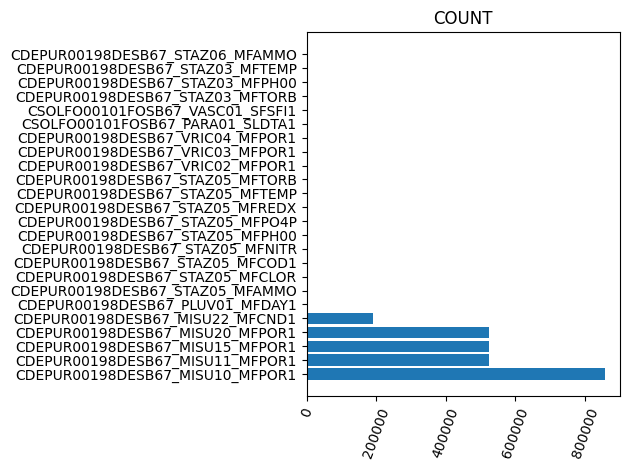

In [91]:
x_data=[]
y_data=[]
for key, device_stats in devices_stats.items():
    x_data.append(key)
    if device_stats and "count" in device_stats["detail"]["value"]:
        y_data.append(device_stats["detail"]["value"]["count"])
    else:
        y_data.append(0)

    print(x_data[-1], y_data[-1])

plt.barh(x_data, y_data)
plt.title("COUNT")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()


## Stats (NESTED)

In [92]:
# totals (jan only)

#start_date="2025-01-01"
#end_date="2025-01-31"

group_by="%Y-%m"
stats="count,avg,max,min"
devices_stats_nested={}
for index, row in df_sensors_info.iterrows():
    endpoint = ENDPOINT_GET_DEVICE_ID_DATA_STATS_NESTED % ( index, row["property"], keys, stats, group_by ) + "&start_date="+start_date+"&end_date="+end_date
    (result, data) = common.get_data(endpoint, token, None)
    devices_stats_nested[index]=data

    print(result, data)
    #print(endpoint)


-- get from  https://api.cssboost.particle-summary.pt/devices/CDEPUR00198DESB67_MISU10_MFPOR1/data/statistics/nested/date/flow_rate/keys/value?statistics=count,avg,max,min&group_by=%Y-%m&start_date=2025-01-01&end_date=2026-01-01
-- data GET OK.
200 {'value': {'avg': {'2025-01': 330.25887656810033, '2025-02': 461.2979290674603, '2025-03': 649.9073022419627, '2025-04': 404.4699884259259, '2025-05': 652.7962085573477, '2025-06': 507.4069039351852, '2025-07': 677.2144657258065, '2025-08': 838.8108590949821, '2025-09': 841.7797395833334, '2025-10': 838.3132646111936, '2025-11': 744.1894914215686, '2025-12': 641.9648129480287, '2026-01': 1279.75}, 'count': {'2025-01': 44640.0, '2025-02': 40320.0, '2025-03': 47280.0, '2025-04': 86400.0, '2025-05': 89280.0, '2025-06': 86400.0, '2025-07': 89280.0, '2025-08': 89280.0, '2025-09': 86400.0, '2025-10': 80760.0, '2025-11': 73440.0, '2025-12': 44640.0, '2026-01': 1.0}, 'max': {'2025-01': 2719.5, '2025-02': 2687.75, '2025-03': 2899.0, '2025-04': 2839.2

In [93]:
def chart_nested_stats(title, data_stats):
    #
    if data_stats and "count" in data_stats["value"]:
        x_values=list(data_stats["value"]["count"].keys())
        count_values=list(data_stats["value"]["count"].values())
        plt.subplot(1,2,1)
        plt.bar(x_values, count_values)
        plt.title(title+" COUNT", fontsize=8)
        plt.xticks(rotation=70)
        plt.tight_layout()
    #    
    if data_stats and "avg" in data_stats["value"]:    
        x_values=list(data_stats["value"]["avg"].keys())
        avg_values=[float(v) for v in data_stats["value"]["avg"].values()] #list(data_stats["value"]["avg"].values())
        max_values=[float(v) for v in data_stats["value"]["max"].values()] #list(data_stats["value"]["max"].values())
        min_values=[float(v) for v in data_stats["value"]["min"].values()] #list(data_stats["value"]["min"].values())
        plt.subplot(1,2,2)
        plt.plot(x_values, avg_values)
        plt.plot(x_values, min_values)
        plt.plot(x_values, max_values)
        plt.title(title+" STATS", fontsize=8)
        plt.xticks(rotation=70)
 
    plt.tight_layout()
    plt.show()
        

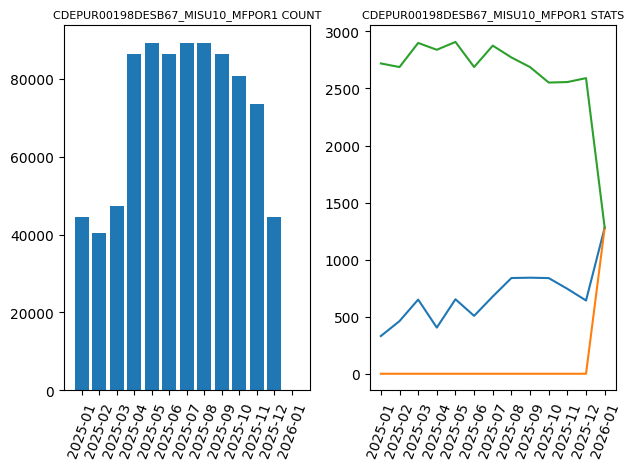

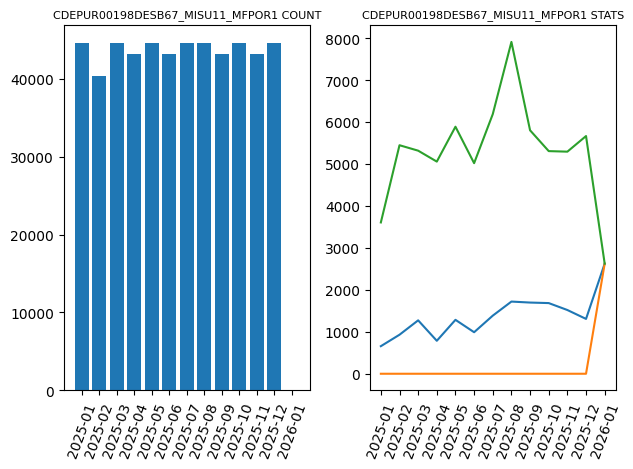

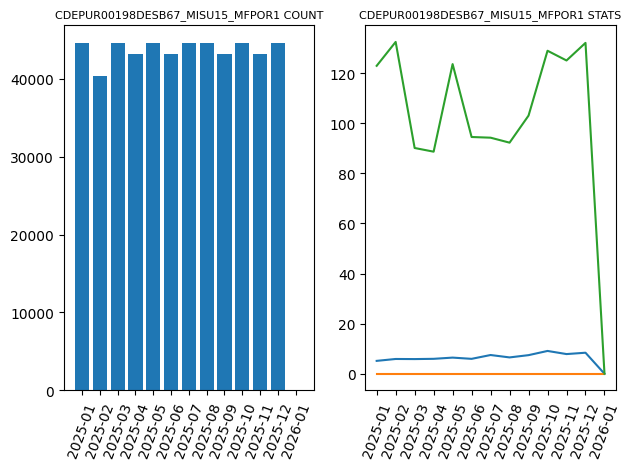

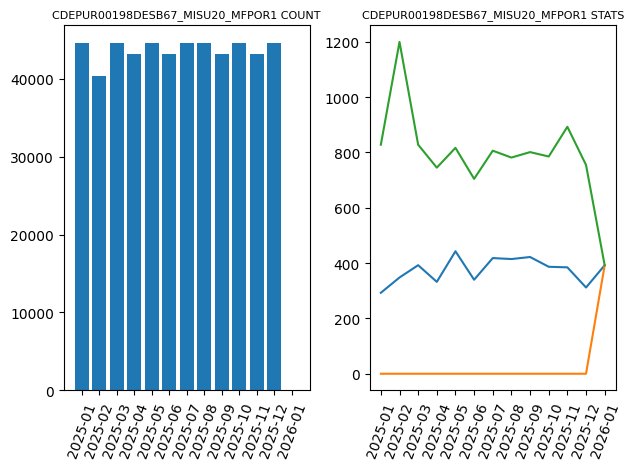

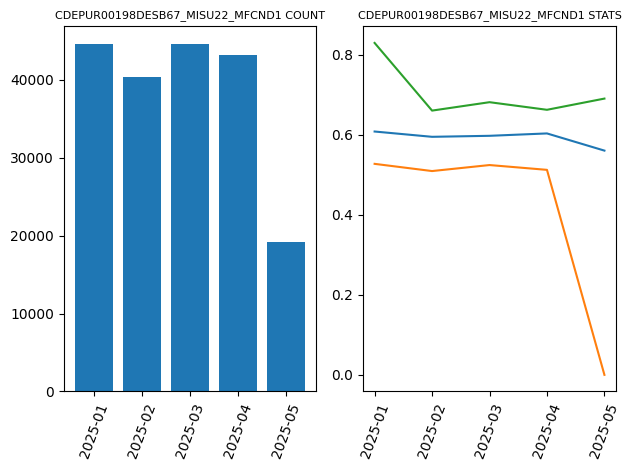

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [94]:
for key, device_stats_nested in devices_stats_nested.items():
    #common_test.chart_nested_stats(key, device_stats_nested)
    chart_nested_stats(key, device_stats_nested)
